# Regresión polinomial: ejemplo completo paso a paso

**Problema:** queremos predecir el **consumo de combustible** de un vehículo (litros cada 100 km) a partir de su **velocidad** (km/h).

Este problema es un buen caso de estudio porque la relación **no es lineal**: a velocidades bajas el motor trabaja en marchas cortas y poco eficientes, a velocidades medias el consumo es mínimo y a velocidades altas la resistencia del aire dispara el consumo. La curva tiene forma de "U", algo que una recta no puede representar.

**Recorrido del notebook:**

1. Generación de datos
3. Exploración de los datos
4. División en entrenamiento y prueba
5. Modelo base: regresión lineal simple (y por qué falla)
6. La transformación polinomial por dentro
7. Regresión polinomial con scikit-learn
8. El efecto del grado: subajuste y sobreajuste
9. Selección del grado con validación cruzada
10. Evaluación final en el conjunto de prueba
11. Análisis de residuos
12. Interpretación del modelo (velocidad óptima)
13. El peligro de extrapolar
14. Conclusiones

## 0. Librerías

- **NumPy**: cálculo numérico y álgebra matricial.
- **pandas**: tablas de datos.
- **matplotlib**: gráficos.
- **scikit-learn**: transformación polinomial, modelos, validación y métricas.

Fijamos una **semilla aleatoria** para que los resultados sean reproducibles: cualquiera que ejecute el notebook obtendrá exactamente los mismos números.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEMILLA = 32
rng = np.random.default_rng(SEMILLA)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 1. Generación de los datos

Usamos datos **sintéticos**: los generamos a partir de una función conocida más ruido aleatorio. La ventaja didáctica es que **conocemos la verdad** y podemos comprobar si el modelo la recupera. En un problema real esta función es desconocida.

La función "verdadera" es:

$$
\text{consumo}(v) = 5.2 + 0.0011\,(v-70)^2 + 0.000008\,(v-70)^3
$$

Tiene un término cuadrático (la "U") y un pequeño término cúbico que la hace **asimétrica**: el consumo sube más rápido a velocidades altas que a bajas, como ocurre en la realidad por la resistencia aerodinámica.

A cada valor le sumamos un **ruido normal** con desviación estándar 0.5 L/100 km. El ruido representa todo lo que no medimos: estilo de conducción, pendiente de la vía, viento, temperatura, etc. Ningún modelo puede predecir el ruido, por lo que **el mejor error posible (RMSE) ronda 0.5**.

In [2]:
def consumo_real(v):
    return 5.2 + 0.0011 * (v - 70)**2 + 0.000008 * (v - 70)**3

n = 60
velocidad = rng.uniform(20, 130, n)
consumo = consumo_real(velocidad) + rng.normal(0, 0.5, n)

df = pd.DataFrame({"velocidad": velocidad, "consumo": consumo}).sort_values("velocidad").reset_index(drop=True)
df.head()

,velocidad,consumo
0,20.955268,6.456266
1,24.459625,5.666647
2,25.126477,6.997991
3,27.333225,7.085901
4,33.108203,5.997579


## 2. Exploración de los datos

Antes de modelar siempre se **miran los datos**. El resumen estadístico muestra rangos y dispersión; el gráfico muestra la **forma** de la relación, que es lo que decide qué modelo usar.

In [3]:
df.describe().round(2)

,velocidad,consumo
count,60.00,60.00
mean,78.89,6.55
std,32.01,1.67
min,20.96,4.37
25%,54.37,5.35
50%,78.00,5.84
75%,109.17,7.23
max,129.01,10.70


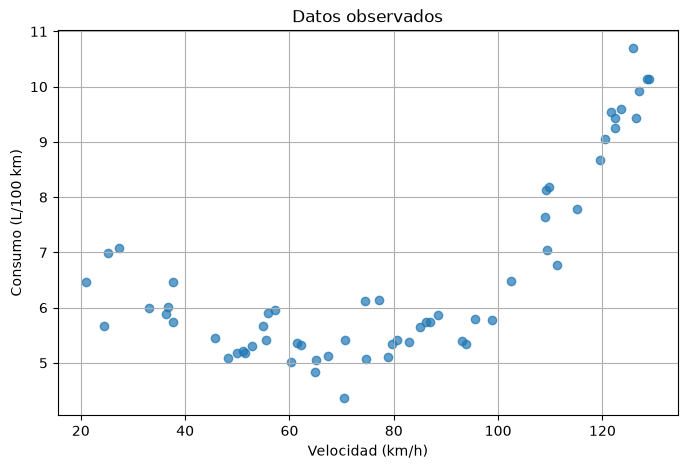

Correlación de Pearson: 0.707


In [4]:
plt.scatter(df["velocidad"], df["consumo"], alpha=0.7)
plt.xlabel("Velocidad (km/h)")
plt.ylabel("Consumo (L/100 km)")
plt.title("Datos observados")
plt.show()

print("Correlación de Pearson:", round(df["velocidad"].corr(df["consumo"]), 3))

**Observaciones:**

- La nube de puntos tiene claramente forma de **U**: el consumo baja hasta unos 60–75 km/h y luego sube.
- El **coeficiente de correlación de Pearson** es apenas moderado (≈ 0.7), aunque en el gráfico la relación se ve muy fuerte. Pearson solo mide cuánto se parece la relación a una **recta**: no detecta curvas. Aquí capta la tendencia general a subir, pero no la "U". Por eso nunca hay que decidir el modelo solo mirando la correlación; siempre hay que graficar.

## 3. División en entrenamiento y prueba

Separamos los datos en dos partes:

- **Entrenamiento (75 %)**: con él se ajusta el modelo y se elige el grado.
- **Prueba (25 %)**: se guarda "bajo llave" y **solo se usa al final**, una vez, para estimar el rendimiento real con datos nunca vistos.

Si usáramos los datos de prueba para tomar decisiones (por ejemplo, elegir el grado), la estimación final sería optimista y engañosa. A esto se le llama **fuga de datos** (*data leakage*).

scikit-learn espera que `X` sea una matriz 2D (filas = observaciones, columnas = variables), por eso usamos `df[["velocidad"]]` con doble corchete.

In [5]:
X = df[["velocidad"]].values   # forma (60, 1)
y = df["consumo"].values       # forma (60,)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEMILLA)

print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)

Entrenamiento: (45, 1)  Prueba: (15, 1)


## 4. Modelo base: regresión lineal simple

Siempre conviene empezar por el modelo más sencillo como **línea base**. Si un modelo más complejo no lo supera, no vale la pena.

$$
\hat{y} = \beta_0 + \beta_1 x
$$

Definimos una función auxiliar para calcular tres métricas que usaremos todo el tiempo:

- **RMSE** (raíz del error cuadrático medio): error típico en las mismas unidades que $y$ (L/100 km). Penaliza más los errores grandes.
- **MAE** (error absoluto medio): error promedio en valor absoluto; más fácil de explicar y menos sensible a errores extremos.
- **R²** (coeficiente de determinación): proporción de la variabilidad de $y$ explicada por el modelo. 1 es perfecto; 0 equivale a predecir siempre el promedio; puede ser negativo si el modelo es peor que eso.

In [6]:
def metricas(y_real, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE": mean_absolute_error(y_real, y_pred),
        "R2": r2_score(y_real, y_pred),
    }

lineal = LinearRegression().fit(X_train, y_train)
print(f"Ecuación: consumo = {lineal.intercept_:.3f} + {lineal.coef_[0]:.4f}·v")
print("Entrenamiento:", {k: round(v, 3) for k, v in metricas(y_train, lineal.predict(X_train)).items()})

Ecuación: consumo = 3.953 + 0.0312·v
Entrenamiento: {'RMSE': np.float64(1.136), 'MAE': 0.953, 'R2': 0.405}


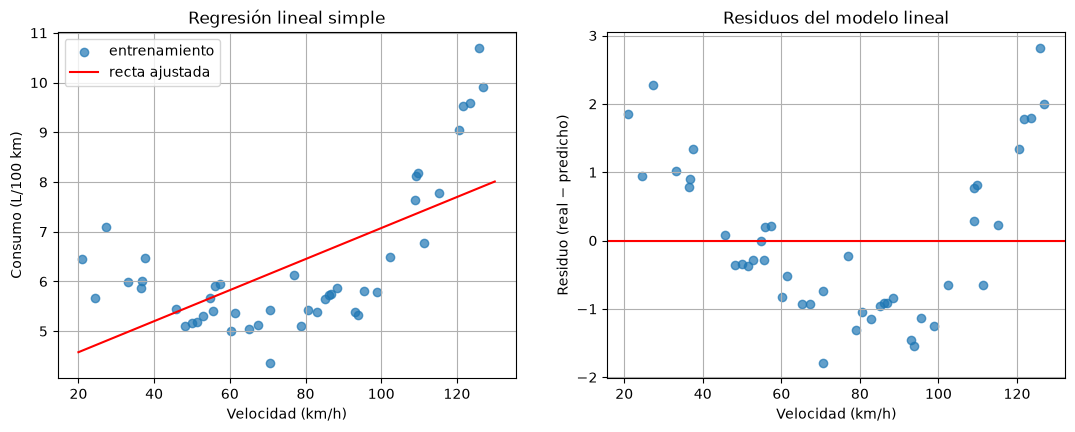

In [7]:
x_graf = np.linspace(20, 130, 300).reshape(-1, 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(X_train, y_train, alpha=0.7, label="entrenamiento")
ax[0].plot(x_graf, lineal.predict(x_graf), color="red", label="recta ajustada")
ax[0].set(xlabel="Velocidad (km/h)", ylabel="Consumo (L/100 km)", title="Regresión lineal simple")
ax[0].legend()

residuos = y_train - lineal.predict(X_train)
ax[1].scatter(X_train, residuos, alpha=0.7)
ax[1].axhline(0, color="red")
ax[1].set(xlabel="Velocidad (km/h)", ylabel="Residuo (real − predicho)", title="Residuos del modelo lineal")
plt.show()

**Diagnóstico:** la recta no sigue la curva. El gráfico de **residuos** es la prueba definitiva: si el modelo fuera adecuado, los residuos estarían dispersos al azar alrededor de cero. Aquí muestran un **patrón en U** muy claro: el modelo subestima en los extremos y sobreestima en el centro.

Un patrón sistemático en los residuos significa que queda estructura en los datos que el modelo no capturó. Esto es **subajuste** (alto sesgo) y es la señal para agregar términos polinomiales.

## 5. La transformación polinomial por dentro

`PolynomialFeatures` toma cada valor $x$ y genera las columnas $x, x^2, \dots, x^d$. Veamos qué produce con grado 3 sobre tres velocidades.

`include_bias=False` evita que agregue una columna de unos, porque `LinearRegression` ya calcula el intercepto $\beta_0$ por su cuenta.

In [8]:
poly3 = PolynomialFeatures(degree=3, include_bias=False)
muestra = np.array([[20], [70], [130]])

pd.DataFrame(poly3.fit_transform(muestra), columns=poly3.get_feature_names_out(["v"]))

,v,v^2,v^3
0,20.0,400.0,8000.0
1,70.0,4900.0,343000.0
2,130.0,16900.0,2197000.0


**Dos cosas importantes que se ven en esta tabla:**

1. El modelo pasa de 1 variable a 3 variables ($v$, $v^2$, $v^3$). Sobre ellas se aplica una **regresión lineal múltiple normal**. Por eso decimos que la regresión polinomial es lineal **en los parámetros**.
2. Las escalas son **muy distintas**: $v$ llega a 130, pero $v^3$ llega a más de dos millones. Con grados altos esto provoca problemas numéricos y columnas muy correlacionadas entre sí (**multicolinealidad**). Por eso más adelante vamos a **estandarizar**.

In [23]:
Xp = PolynomialFeatures(degree=3, include_bias=False).fit_transform(X_train)
print("Correlación entre columnas v, v², v³:")
print(np.corrcoef(Xp.T).round(3))

Correlación entre columnas v, v², v³:
[[1.    0.982 0.946]
 [0.982 1.    0.989]
 [0.946 0.989 1.   ]]


Correlaciones de 0.97 o más entre columnas: las potencias de $x$ "se mueven juntas". Esto no afecta mucho la calidad de las predicciones, pero sí vuelve inestables los coeficientes individuales.

## 6. Regresión polinomial con scikit-learn

La forma recomendada es un **Pipeline** con tres pasos:

1. `PolynomialFeatures(d)`: genera $x, x^2, \dots, x^d$.
2. `StandardScaler()`: estandariza cada columna (media 0, desviación 1) y resuelve el problema de escalas.
3. `LinearRegression()`: ajusta los coeficientes por mínimos cuadrados.

**¿Por qué un Pipeline y no hacer los pasos por separado?** Porque garantiza que el escalador aprenda la media y la desviación **solo con los datos de entrenamiento** de cada partición. Si escaláramos todo el conjunto antes de dividir, la información de prueba se "filtraría" en el entrenamiento.

In [12]:
def modelo_polinomial(grado):
    return make_pipeline(
        PolynomialFeatures(degree=grado, include_bias=False),
        StandardScaler(),
        LinearRegression(),
    )

m2 = modelo_polinomial(2).fit(X_train, y_train)
print("Grado 2 — entrenamiento:", {k: round(v, 3) for k, v in metricas(y_train, m2.predict(X_train)).items()})
print("Grado 1 — entrenamiento:", {k: round(v, 3) for k, v in metricas(y_train, lineal.predict(X_train)).items()})

Grado 2 — entrenamiento: {'RMSE': np.float64(0.501), 'MAE': 0.373, 'R2': 0.884}
Grado 1 — entrenamiento: {'RMSE': np.float64(1.136), 'MAE': 0.953, 'R2': 0.405}


Con solo agregar $v^2$ el RMSE cae drásticamente y el R² sube mucho: el modelo ahora captura la forma en U.

## 7. El efecto del grado: subajuste y sobreajuste

Ajustamos modelos de grados 1, 2, 3, 6, 12 y 20 y los graficamos. Para cada uno comparamos el RMSE en entrenamiento con el RMSE en prueba (**solo como ilustración**: la elección real del grado se hace en la sección siguiente con validación cruzada, sin mirar la prueba).

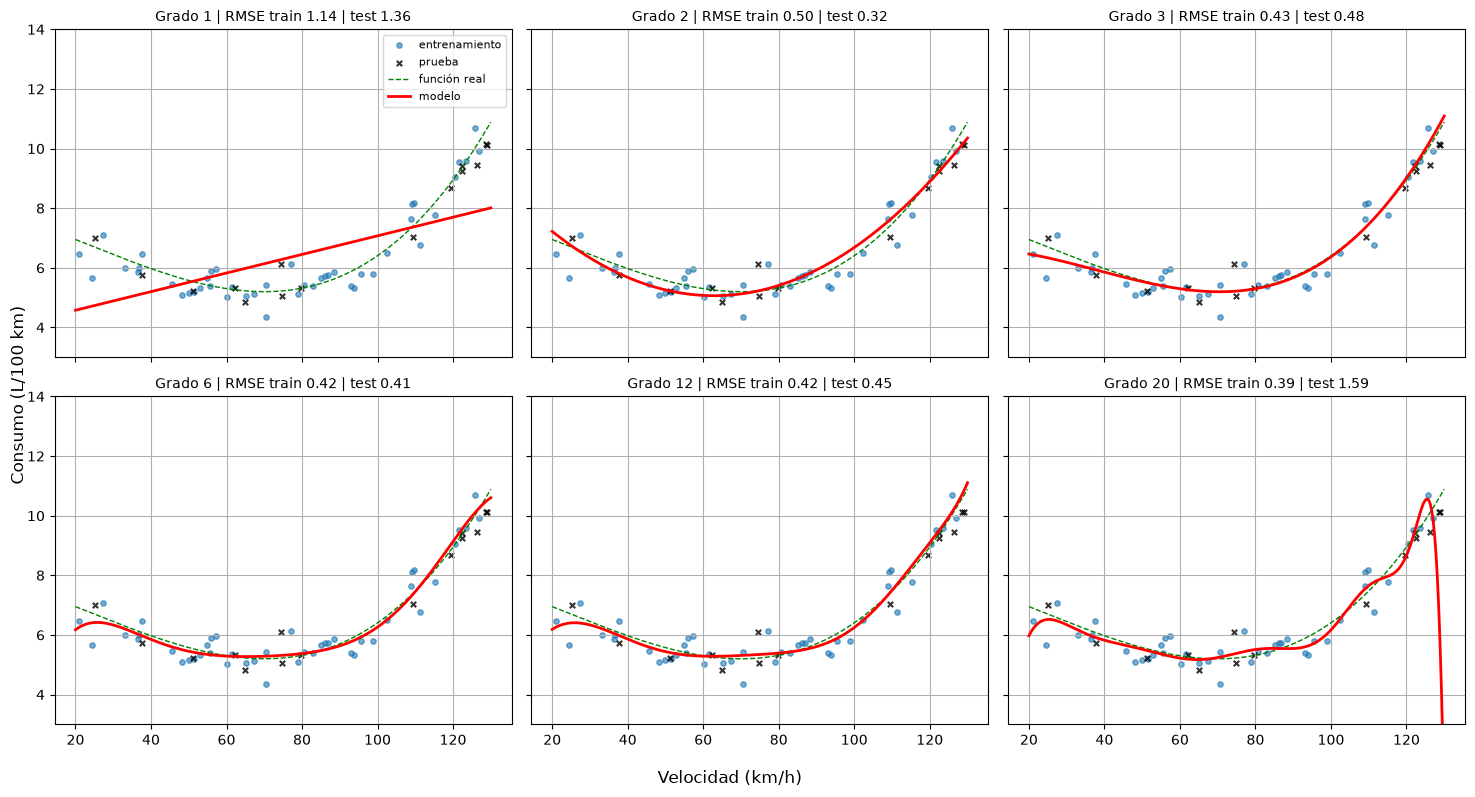

In [13]:
grados = [1, 2, 3, 6, 12, 20]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for ax, g in zip(axes.ravel(), grados):
    m = modelo_polinomial(g).fit(X_train, y_train)
    rmse_tr = metricas(y_train, m.predict(X_train))["RMSE"]
    rmse_te = metricas(y_test, m.predict(X_test))["RMSE"]
    ax.scatter(X_train, y_train, s=15, alpha=0.6, label="entrenamiento")
    ax.scatter(X_test, y_test, s=15, alpha=0.8, marker="x", color="black", label="prueba")
    ax.plot(x_graf, consumo_real(x_graf), "g--", lw=1, label="función real")
    ax.plot(x_graf, m.predict(x_graf), "r", lw=2, label="modelo")
    ax.set_title(f"Grado {g} | RMSE train {rmse_tr:.2f} | test {rmse_te:.2f}", fontsize=10)
    ax.set_ylim(3, 14)

axes[0, 0].legend(fontsize=8)
fig.supxlabel("Velocidad (km/h)"); fig.supylabel("Consumo (L/100 km)")
plt.tight_layout(); plt.show()

**Lectura de los gráficos:**

- **Grado 1 — subajuste:** error alto en entrenamiento y prueba. El modelo es demasiado rígido (alto **sesgo**).
- **Grados 2 y 3 — buen ajuste:** la curva roja casi coincide con la función real (verde). El error en prueba se acerca al nivel del ruido (~0.5).
- **Grados 12 y 20 — sobreajuste:** el error de entrenamiento sigue bajando, pero la curva empieza a **ondular** para perseguir el ruido de puntos individuales, sobre todo en los extremos (fenómeno de Runge). Es un modelo con alta **varianza**: si cambiáramos un poco los datos, la curva cambiaría mucho.

La lección clave: **el error de entrenamiento siempre baja al subir el grado**, por eso nunca sirve para elegir el grado.

Notarás también que el grado 2 obtiene un error de prueba algo menor que el grado 3. Con solo 15 observaciones de prueba, diferencias pequeñas entre modelos parecidos se deben en buena parte al azar de qué puntos cayeron en la prueba. Esa es otra razón para **no** elegir el grado mirando el conjunto de prueba, sino con validación cruzada, que promedia varias particiones.

## 8. Selección del grado con validación cruzada

La **validación cruzada k-fold** (aquí k = 5) divide el conjunto de **entrenamiento** en 5 partes. Entrena 5 veces, usando cada vez 4 partes para ajustar y la restante para validar. El promedio de los 5 errores de validación estima cómo se comportará el modelo con datos nuevos, **sin tocar el conjunto de prueba**.

`shuffle=True` mezcla los datos antes de dividirlos; es importante aquí porque nuestro DataFrame está ordenado por velocidad y, sin mezclar, cada fold cubriría un rango de velocidades distinto.

In [14]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
resultados = []

for g in range(1, 16):
    cv = cross_validate(modelo_polinomial(g), X_train, y_train, cv=kf,
                        scoring="neg_root_mean_squared_error", return_train_score=True)
    resultados.append({"grado": g,
                       "RMSE_entrenamiento": -cv["train_score"].mean(),
                       "RMSE_validacion": -cv["test_score"].mean(),
                       "desv_validacion": cv["test_score"].std()})

res = pd.DataFrame(resultados)
res.round(3)

,grado,RMSE_entrenamiento,RMSE_validacion,desv_validacion
0,1,1.130,1.166,0.173
1,2,0.499,0.516,0.068
2,3,0.424,0.463,0.035
3,4,0.423,0.472,0.034
4,5,0.422,0.476,0.034
5,6,0.414,0.498,0.048
6,7,0.410,0.583,0.188
7,8,0.410,0.563,0.140
8,9,0.407,0.575,0.115
9,10,0.404,0.671,0.273


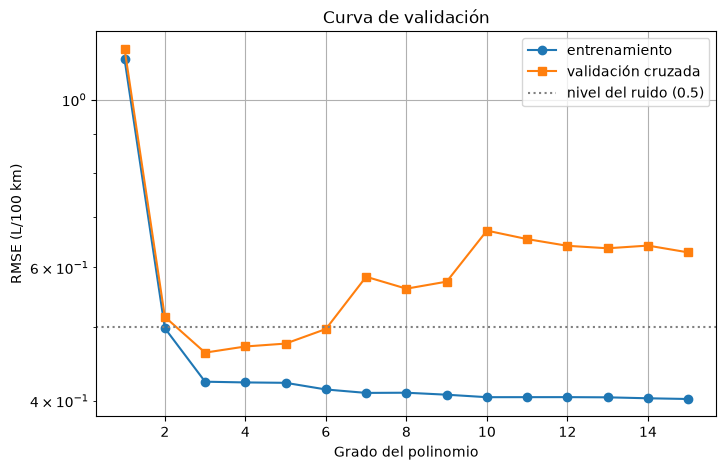

Grado con menor RMSE de validación: 3


In [15]:
plt.plot(res["grado"], res["RMSE_entrenamiento"], "o-", label="entrenamiento")
plt.plot(res["grado"], res["RMSE_validacion"], "s-", label="validación cruzada")
plt.axhline(0.5, color="gray", ls=":", label="nivel del ruido (0.5)")
plt.xlabel("Grado del polinomio"); plt.ylabel("RMSE (L/100 km)")
plt.yscale("log"); plt.title("Curva de validación")
plt.legend(); plt.show()

mejor_grado = int(res.loc[res["RMSE_validacion"].idxmin(), "grado"])
print("Grado con menor RMSE de validación:", mejor_grado)

Esta es la **curva de validación** y es el gráfico más importante del notebook:

- La curva de **entrenamiento** baja siempre.
- La curva de **validación** baja al principio, llega a un mínimo y luego **sube**: ese aumento es el sobreajuste.
- La **separación** entre ambas curvas mide cuánto sobreajusta el modelo.

**Regla de parsimonia:** si varios grados tienen errores de validación muy parecidos, se prefiere el **más simple** (menor grado). Un criterio común es la "regla de una desviación estándar": elegir el grado más bajo cuyo error esté dentro de una desviación estándar del mínimo.

In [16]:
fila_min = res.loc[res["RMSE_validacion"].idxmin()]
umbral = fila_min["RMSE_validacion"] + fila_min["desv_validacion"] / np.sqrt(kf.get_n_splits())
grado_simple = int(res.loc[res["RMSE_validacion"] <= umbral, "grado"].min())
print(f"Umbral (mínimo + 1 error estándar): {umbral:.3f}")
print("Grado más simple dentro del umbral:", grado_simple)

Umbral (mínimo + 1 error estándar): 0.479
Grado más simple dentro del umbral: 3


Lo mismo se puede automatizar con **GridSearchCV**, que prueba todos los valores de un hiperparámetro con validación cruzada y reentrena automáticamente el mejor modelo con todo el conjunto de entrenamiento.

El nombre `polynomialfeatures__degree` sigue la convención `paso__parámetro` de los pipelines (doble guion bajo).

In [17]:
busqueda = GridSearchCV(modelo_polinomial(1),
                        param_grid={"polynomialfeatures__degree": range(1, 16)},
                        cv=kf, scoring="neg_root_mean_squared_error")
busqueda.fit(X_train, y_train)
print("Mejor grado (GridSearchCV):", busqueda.best_params_["polynomialfeatures__degree"])
print(f"RMSE de validación: {-busqueda.best_score_:.3f}")

Mejor grado (GridSearchCV): 3
RMSE de validación: 0.463


## 9. Evaluación final en el conjunto de prueba

Ahora sí, **una única vez**, evaluamos con los datos de prueba. Usamos el grado elegido por la regla de parsimonia y lo comparamos con el modelo lineal base.

In [18]:
modelo_final = modelo_polinomial(grado_simple).fit(X_train, y_train)

comparacion = pd.DataFrame({
    "Lineal (grado 1)": metricas(y_test, lineal.predict(X_test)),
    f"Polinomial (grado {grado_simple})": metricas(y_test, modelo_final.predict(X_test)),
}).T
comparacion.round(3)

,RMSE,MAE,R2
Lineal (grado 1),1.359,1.182,0.522
Polinomial (grado 3),0.476,0.381,0.941


El modelo polinomial reduce el error de prueba de forma drástica frente a la recta, y su RMSE queda cerca de 0.5, que es el **límite teórico** impuesto por el ruido. Un RMSE mucho menor que 0.5 en prueba sería sospechoso.

**Interpretación práctica del RMSE:** al predecir el consumo de un auto a cierta velocidad, el modelo se equivoca típicamente en alrededor de medio litro cada 100 km.

## 10. Análisis de residuos del modelo final

Revisamos los supuestos de la regresión con dos gráficos:

1. **Residuos vs. predicción:** deben estar dispersos al azar alrededor de 0, sin patrones (curvas) y con dispersión constante (**homocedasticidad**).
2. **Histograma de residuos:** debería parecerse a una distribución normal centrada en 0.

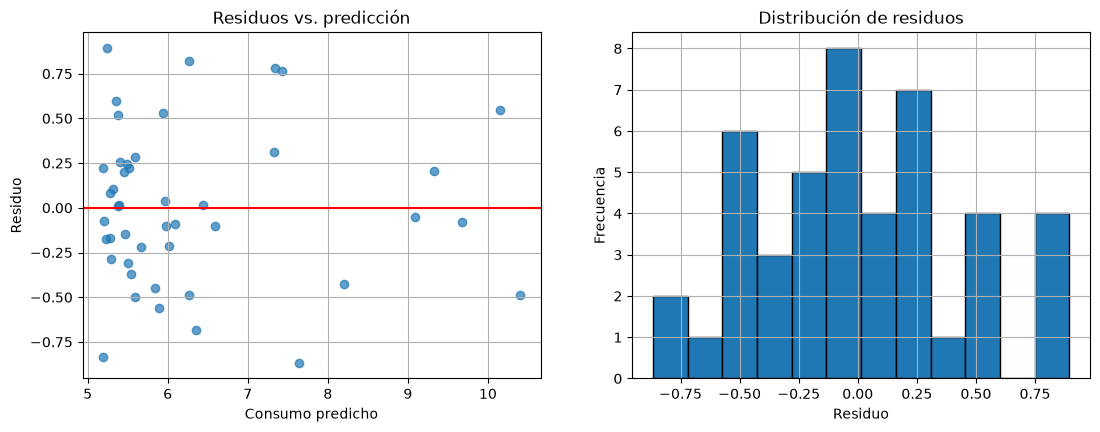

Media de residuos: -0.0000   Desviación: 0.428


In [19]:
pred_tr = modelo_final.predict(X_train)
res_tr = y_train - pred_tr

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(pred_tr, res_tr, alpha=0.7)
ax[0].axhline(0, color="red")
ax[0].set(xlabel="Consumo predicho", ylabel="Residuo", title="Residuos vs. predicción")
ax[1].hist(res_tr, bins=12, edgecolor="black")
ax[1].set(xlabel="Residuo", ylabel="Frecuencia", title="Distribución de residuos")
plt.show()

print(f"Media de residuos: {res_tr.mean():.4f}   Desviación: {res_tr.std():.3f}")

A diferencia del modelo lineal, ya **no hay patrón en U**: los residuos se ven aleatorios. La desviación de los residuos se aproxima al ruido real (0.5). El modelo capturó toda la estructura recuperable de los datos.

## 11. Interpretación: ¿a qué velocidad se consume menos?

Como los coeficientes del Pipeline están en la escala **estandarizada**, no son directamente interpretables. Para obtener la ecuación en unidades originales ajustamos el mismo polinomio con `np.polyfit` (los coeficientes vienen del grado mayor al menor).

En un polinomio, el efecto de la velocidad **no es constante**: la pendiente es la derivada $\frac{d\,\text{consumo}}{dv}$, que cambia según la velocidad. La velocidad de consumo mínimo es donde la derivada vale cero.

In [20]:
coef = np.polyfit(X_train.ravel(), y_train, deg=grado_simple)
p = np.poly1d(coef)
dp = p.deriv()

print("Ecuación en unidades originales:")
print(p)

# Buscar la velocidad de consumo mínimo dentro del rango observado
v_fina = np.linspace(20, 130, 10001)
v_opt = v_fina[np.argmin(p(v_fina))]
v_opt_real = v_fina[np.argmin(consumo_real(v_fina))]
print(f"\nVelocidad óptima estimada: {v_opt:.1f} km/h  → consumo {p(v_opt):.2f} L/100 km")
print(f"Velocidad óptima real    : {v_opt_real:.1f} km/h  → consumo {consumo_real(v_opt_real):.2f} L/100 km")

for vel in [40, 70, 110]:
    print(f"A {vel} km/h la pendiente es {dp(vel):+.4f} L/100 km por cada km/h adicional")

Ecuación en unidades originales:
           3            2
1.062e-05 x - 0.001214 x + 0.01274 x + 6.61

Velocidad óptima estimada: 70.5 km/h  → consumo 5.20 L/100 km
Velocidad óptima real    : 70.0 km/h  → consumo 5.20 L/100 km
A 40 km/h la pendiente es -0.0334 L/100 km por cada km/h adicional
A 70 km/h la pendiente es -0.0010 L/100 km por cada km/h adicional
A 110 km/h la pendiente es +0.1313 L/100 km por cada km/h adicional


**Lectura:** el modelo recupera una velocidad óptima muy cercana a la real. Las pendientes muestran que el efecto de acelerar depende del punto de partida: a 40 km/h, ir más rápido **reduce** el consumo (pendiente negativa); a 110 km/h, cada km/h adicional lo **aumenta** (pendiente positiva y cada vez mayor).

Esta es la forma correcta de interpretar un modelo polinomial: a través de la curva y sus derivadas, **no** mirando cada coeficiente por separado.

## 12. El peligro de extrapolar

Los datos cubren velocidades entre 20 y 130 km/h. ¿Qué pasa si pedimos predicciones fuera de ese rango?

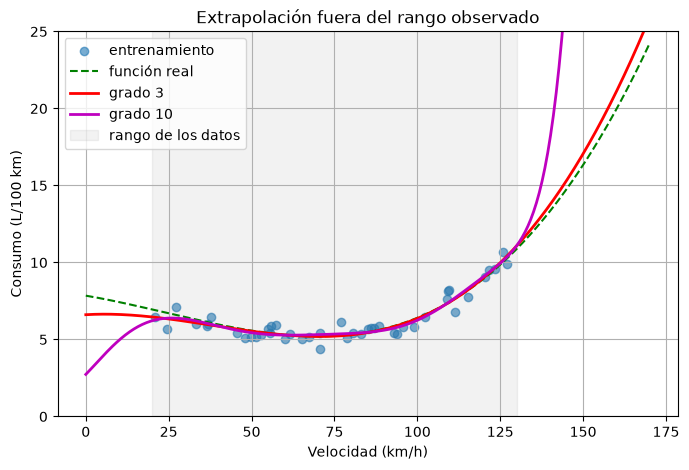

Predicción a 160 km/h — grado 3: 21.09 | grado 10: 164.47 | real: 19.94


In [21]:
x_ext = np.linspace(0, 170, 400).reshape(-1, 1)
m_alto = modelo_polinomial(10).fit(X_train, y_train)

plt.scatter(X_train, y_train, alpha=0.6, label="entrenamiento")
plt.plot(x_ext, consumo_real(x_ext), "g--", label="función real")
plt.plot(x_ext, modelo_final.predict(x_ext), "r", lw=2, label=f"grado {grado_simple}")
plt.plot(x_ext, m_alto.predict(x_ext), "m", lw=2, label="grado 10")
plt.axvspan(20, 130, color="gray", alpha=0.1, label="rango de los datos")
plt.ylim(0, 25); plt.xlabel("Velocidad (km/h)"); plt.ylabel("Consumo (L/100 km)")
plt.title("Extrapolación fuera del rango observado"); plt.legend(); plt.show()

print(f"Predicción a 160 km/h — grado {grado_simple}: {modelo_final.predict([[160]])[0]:.2f} | "
      f"grado 10: {m_alto.predict([[160]])[0]:.2f} | real: {consumo_real(160):.2f}")

Dentro de la zona gris ambos modelos son razonables, pero fuera de ella el polinomio de grado alto **se dispara**, porque los términos $v^{10}$ dominan rápidamente. Incluso el modelo de grado bajo pierde precisión conforme nos alejamos.

**Regla:** la regresión polinomial sirve para **interpolar** (predecir dentro del rango observado), no para extrapolar.

## 13. Conclusiones

1. La regresión polinomial modela relaciones **curvas** agregando potencias de $x$, pero sigue siendo una regresión **lineal en los parámetros** y se resuelve con mínimos cuadrados.
2. Los **residuos** con patrón son la señal de que un modelo lineal no basta.
3. El **grado** controla el equilibrio sesgo-varianza: poco grado → subajuste; demasiado → sobreajuste.
4. El grado se elige con **validación cruzada**, nunca con el error de entrenamiento ni con el conjunto de prueba.
5. Conviene **escalar** (dentro de un Pipeline) para evitar problemas numéricos y multicolinealidad.
6. El modelo se interpreta mediante la **curva y sus derivadas**, no con coeficientes aislados.
7. **No se debe extrapolar** fuera del rango de los datos.
8. **Ridge** permite usar grados altos controlando el sobreajuste.
